# CLT demo

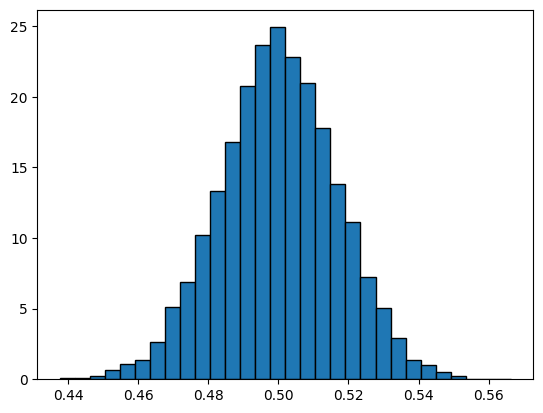

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Paramters for uniform distribution
num_samples = 10000
sample_size = 300
distribution_range = (0, 1)

# Generate samples from an uniform distribution
samples = np.random.uniform(distribution_range[0], distribution_range[1], (num_samples, sample_size))

# Calculate the sample means
sample_means = np.mean(samples, axis=1) #axis=1 for each row

# Plot histogram of sample means
plt.hist(sample_means, bins=30, density=True, edgecolor='black')
plt.show()

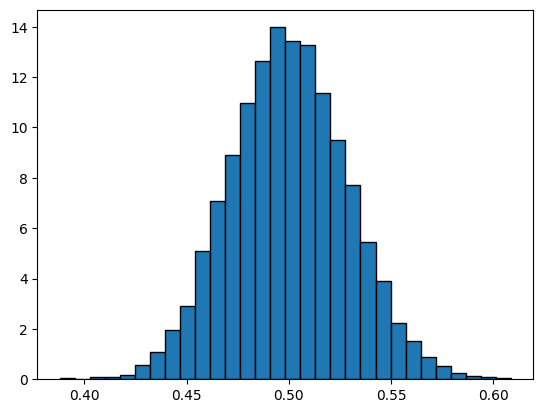

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Paramters for exponential distribution
num_samples = 10000
sample_size = 300
lambda_param = 2

# Generate samples from an exponential distribution
samples = np.random.exponential(scale=1/lambda_param, size=(num_samples, sample_size))

# Calculate the sample means
sample_means = np.mean(samples, axis=1) #axis=1 for each row

# Plot histogram of sample means
plt.hist(sample_means, bins=30, density=True, edgecolor='black')
plt.show()

# CLT case study on titanic dataset

In [1]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


<Axes: ylabel='Density'>

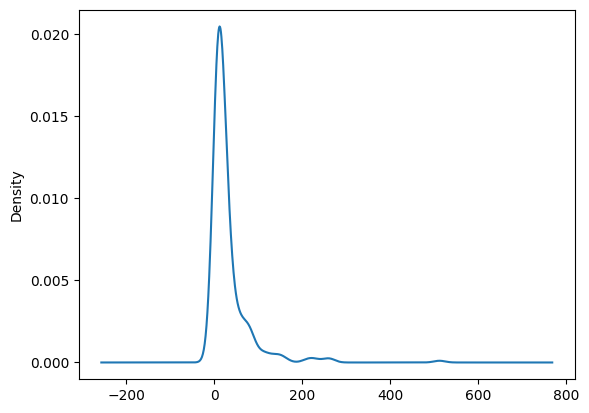

In [2]:
# Fare is a right skewed distribution
df['Fare'].plot(kind='kde')

In [6]:
# Generate 1000 samples of size 50 of 'Fare'
samples = []
for i in range(1000):
  samples.append(df['Fare'].sample(50).values.tolist())

In [7]:
samples = np.array(samples)

<Axes: ylabel='Density'>

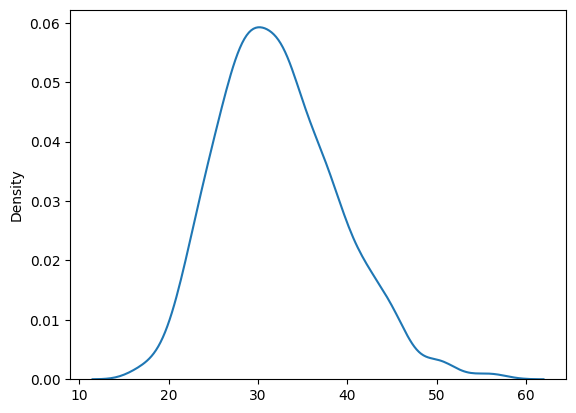

In [8]:
# Calculate the sample means
sampling_means = samples.mean(axis=1)

# Plot kdeplot of sample means
import seaborn as sns
sns.kdeplot(sampling_means)

In [16]:
sampling_means.mean()

np.float64(32.277586102)

In [17]:
df['Fare'].mean()

np.float64(32.204207968574636)

In [13]:
sampling_means.std()/np.sqrt(50)

np.float64(0.9475851102264933)

In [25]:
sampling_means.std()*np.sqrt(50)

np.float64(47.379255511324665)

In [24]:
df['Fare'].std()

49.693428597180905

In [27]:
lower = sampling_means.mean() - 2*sampling_means.std()/np.sqrt(50)
upper = sampling_means.mean() + 2*sampling_means.std()/np.sqrt(50)
print('The range is', lower, '-', upper)

The range is 30.382415881547015 - 34.17275632245299


# CLT case study - Avg. income of Indians

In [30]:
# Generating Random representative sample of salaries (in thousands)
population_size = 100000
population_salaries = np.random.lognormal(mean=4.5, sigma=0.8, size=population_size)

# Generating samples from population and calculating sample means and std.
num_samples = 100
sample_size = 50
sample_means = []
sample_std_devs = []

for i in range(num_samples):
  sample_salaries = np.random.choice(population_salaries, size=sample_size)
  sample_means.append(np.mean(sample_salaries))
  sample_std_devs.append(np.std(sample_salaries))

# Calculating the average of the sample means and the standard error
mean_of_sample_means = np.mean(sample_means)
std_of_sample_means = np.std(sample_means)/np.sqrt(num_samples)

# Calculating 95% confidence interval
lower_bound = mean_of_sample_means - 1.96*std_of_sample_means
upper_bound = mean_of_sample_means + 1.96*std_of_sample_means

# Displaying the results
print("Estimated average annual salary (in thousands):", mean_of_sample_means)
print(f"95% confidence interval (in thousands): {lower_bound} - {upper_bound}")

Estimated average annual salary (in thousands): 124.77751354284865
95% confidence interval (in thousands): 121.46899256423552 - 128.08603452146178
